# در این مثال داده های زمانی تقاضای کالاهای مصرفی یک پالایشگاه مورد استفاده قرار گرفته است.  ابتدا وضعیت موجود شامل میزان تقاضاها، طبقه بندی کالاها از نظر مصرف، روند کمبود تامین کالا بررسی می شود و سپس با مدل جنگل تصادفی پیش بینی تقاضای آتی و میزان حداقل و حداکثر موجودی انبار استخراج می شود.  
فایل را دانلود و در پوشه کاری قرار دهید
spareParts.csv

!pip install pmarima

### فراخوانی کتابخانه ها و توابع مورد نیاز

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime, timedelta
import jdatetime
from jdatetime import date as jdate
from datetime import date
from sklearn.ensemble import RandomForestRegressor

### تابع تبدیل تاریخ شمسی به میلادی
def convert_to_gregorian(shamsi_date):
    x = str(shamsi_date)
    year=x[0:4]
    month=x[4:6]
    day =x[6:8]
    return jdatetime.date(int(year),int(month),int(day)).togregorian()

### فراخوانی داده و پیش پردازش

In [2]:
df = pd.read_csv('spareParts.csv')
df['Date'] = df['Issue Date'].apply(convert_to_gregorian)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by=['Date','Code'], ascending=True)
df.head(10)

,Code,Issue Date,Uom,Req Qty,Issue Qty,Date
1,22016552,13991126,LT,208,208,2021-02-14
0,22048551,13991126,LT,1040,1040,2021-02-14
4,13260022,13991219,LT,624,624,2021-03-09
6,13260522,13991219,LT,624,624,2021-03-09
5,13847012,13991219,LT,624,624,2021-03-09
7,13847012,13991219,LT,1540,1540,2021-03-09
2,22060692,13991219,LT,440,440,2021-03-09
3,28069722,13991219,LT,416,416,2021-03-09
8,28680022,13991225,LT,208,208,2021-03-15
9,66511001,14000119,KG,20,2,2021-04-08


### میزان مصرف قطعات در طول بازه

In [3]:
sum_spare = df.groupby('Code').agg(
                            Req_Qty_Sum=('Req Qty', 'sum'),
                            Uom=('Uom','first')
).sort_values(by='Req_Qty_Sum', ascending=False)
sum_spare

,Req_Qty_Sum,Uom
Code,,
22016552,81396,LT
13847012,20984,LT
22017822,19214,LT
27323321,16432,LT
22048551,11292,LT
28069722,7296,LT
13260522,7280,LT
13260022,6240,LT
26185022,3736,LT


### تحلیل ABC (دسته بندی کالاها)
A گروه قطعات پرمصرف

B  گروه مصرف متوسط

C گروه مصرف کم

In [4]:
abc = df.groupby('Code')['Req Qty'].sum().sort_values(ascending=False).reset_index()
abc['CumSum'] = abc['Req Qty'].cumsum()
abc['Total'] = abc['Req Qty'].sum()
abc['Percent'] = (abc['CumSum'] / abc['Total']) * 100

def classify(p):
    if p<= 80: return 'A'
    elif p<=95: return 'B'
    else: return 'C'

abc['Category'] = abc['Percent'].apply(classify)

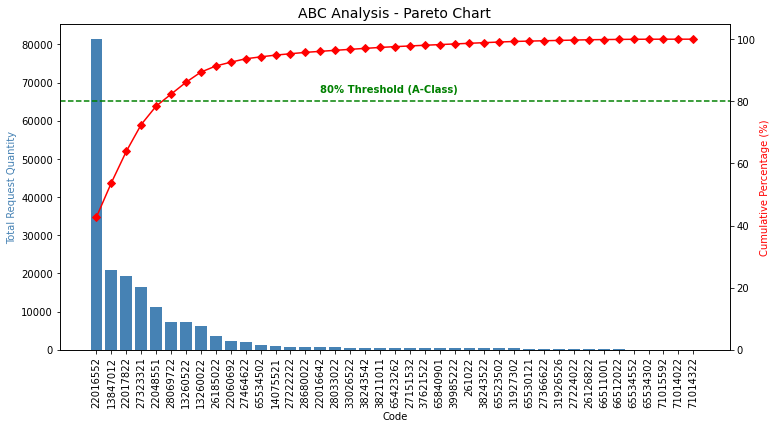

In [5]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.bar(abc['Code'].astype(str), abc['Req Qty'], color='steelblue', label='Quantity')
ax1.set_xlabel('Code')
ax1.set_ylabel('Total Request Quantity', color='steelblue')
ax1.tick_params(axis='x', rotation=90)

ax2 = ax1.twinx()
ax2.plot(abc['Code'].astype(str).to_numpy(), abc['Percent'].to_numpy(), color='red', marker='D', ms=5, label='Cumulative %')
ax2.set_ylabel('Cumulative Percentage (%)', color='red')
ax2.set_ylim(0,105)

ax2.axhline(80, color='green', linestyle='--')
ax2.annotate('80% Threshold (A-Class)', xy=(0, 80), xytext=(15, 83), color='green', fontweight='bold')

plt.title('ABC Analysis - Pareto Chart', fontsize=14)
plt.show()

مقادیر کالا براساس میزان تقاضا مرتب شده اند. حدود 80 درصد این کالا نیز مشخص شده است.

### تحلیل سطح سرویس 
مقدار درخواستی تقسیم بر مقدار تحویلی

In [6]:
total_req = df['Req Qty'].sum()
total_issue = df['Issue Qty'].sum()

service_level = total_issue / total_req

print('Total Requested:', total_req)
print('Total Issued:', total_issue)
print('Service Level:', service_level)

Total Requested: 190303
Total Issued: 173876
Service Level: 0.913679763324803


In [7]:
service_by_item = df.groupby('Code').agg(
    Total_Request=('Req Qty', 'sum'),
    Total_Issued=('Issue Qty', 'sum')
).reset_index()

service_by_item['Service_Level'] = service_by_item['Total_Issued'] / service_by_item['Total_Request']
# مرتب سازی براساس سطح سرویس
service_by_item = service_by_item.sort_values(by='Service_Level')
service_by_item.head(10)

,Code,Total_Request,Total_Issued,Service_Level
14,27224022,208,0,0.000000
11,26185022,3736,1040,0.278373
29,65423262,481,200,0.415800
36,66511001,108,74,0.685185
37,66512022,98,72,0.734694
4,14075521,1076,832,0.773234
30,65523502,385,310,0.805195
3,13847012,20984,16948,0.807663
1,13260022,6240,5200,0.833333
33,65534502,1174,990,0.843271


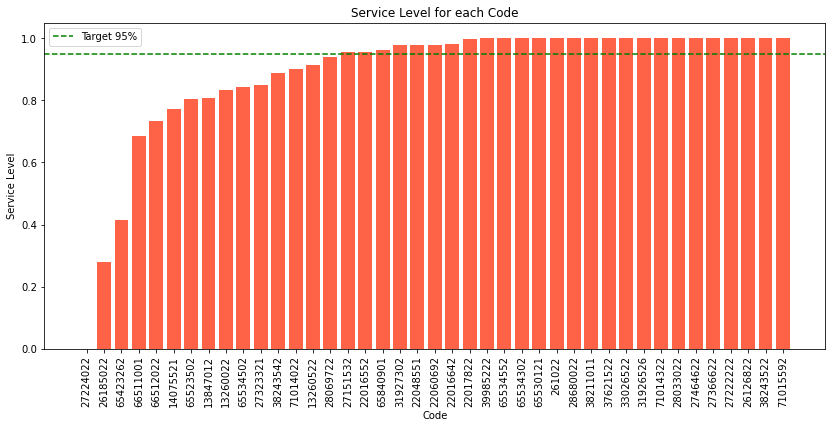

In [8]:
plt.figure(figsize=(14,6))

plt.bar(service_by_item['Code'].astype(str), service_by_item['Service_Level'], color='tomato')
plt.axhline(0.95, color='green', linestyle='--', label='Target 95%')

plt.xticks(rotation=90)
plt.ylabel('Service Level')
plt.xlabel('Code')
plt.title('Service Level for each Code')
plt.legend()
plt.show()

کالا ها براساس میزان کمبود و عدم توانایی در تامین به موقع آن مرتب شده است. این مقادیر از صفر تا 95 درصد در زیر خط سبز مشخص شده است.

### تحلیل کمبود براساس اهمیت کالاها

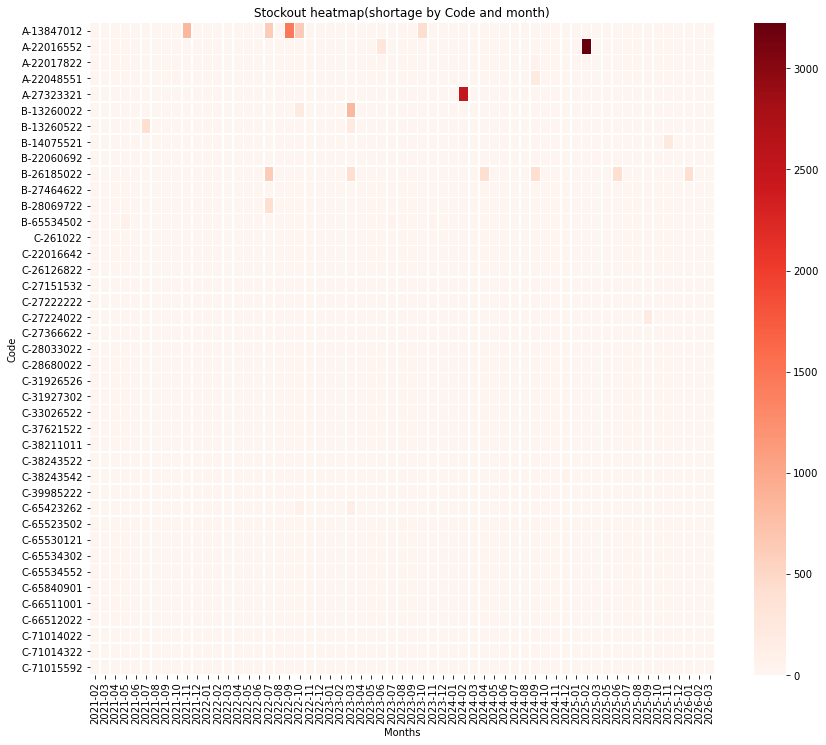

In [9]:
df['Shortage'] = df['Req Qty'] - df['Issue Qty']
df['Month'] = df['Date'].dt.to_period('M')

# کمبود هر قطعه در ماه
shortage_monthly = df.groupby(['Code', 'Month'])['Shortage'].sum().reset_index()

# افزودن دسته بندی کالا
shortage_with_abc = shortage_monthly.merge(abc[['Code','Category']],
                                          on='Code',
                                          how='left'
                                          )
heatmap_data = shortage_with_abc.pivot_table(
    index=['Category','Code'],
    columns='Month',
    values='Shortage',
    fill_value=0
)

category_order = ['A', 'B', 'C']
heatmap_data = heatmap_data.reindex(category_order, level=0)


plt.figure(figsize=(14,12))
ax = sns.heatmap(heatmap_data, cmap='Reds', linewidth=0.5)

plt.title('Stockout heatmap(shortage by Code and month)')
plt.ylabel('Code')
plt.xlabel('Months')


plt.show()

### پیش بینی تقاضا برای گروه A
### براساس مدل جنگل تصادفی
#### از آنجایی که کالا از انبار اصلی به انبارهای داخلی منتقل می شود. تقاضاها می توانند سه ماهه درخواست داده شوند. لحاظ برای بهبود یادگیری مدل باید ماه هایی که تقاضا وجود ندارد مقدار صفر به عنوان تقاضا لحاظ شود تا مدل دچار خطا نشود.

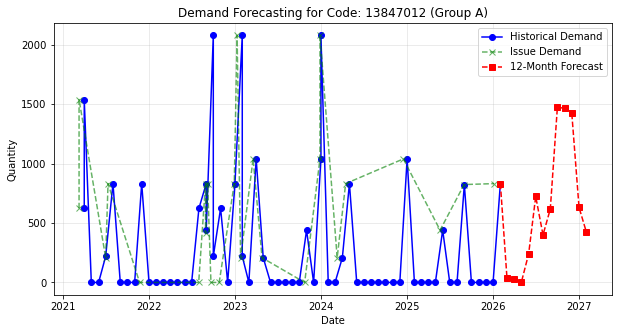

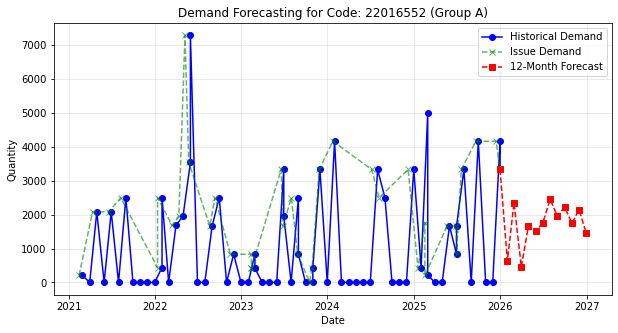

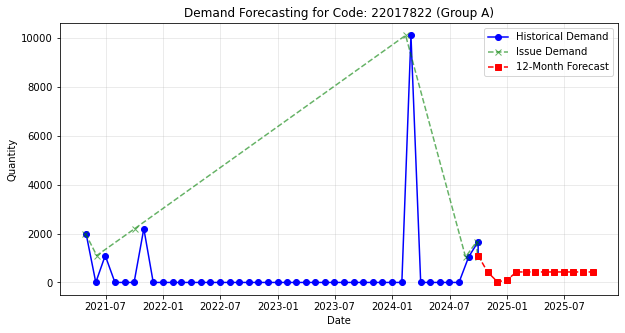

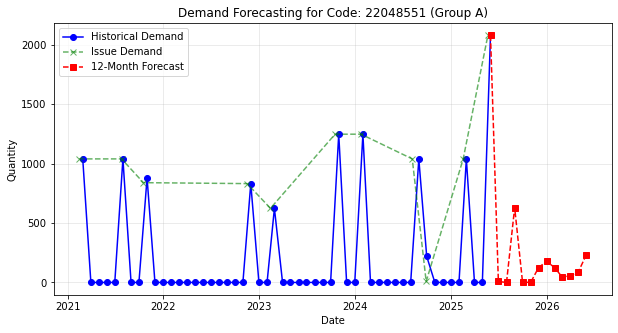

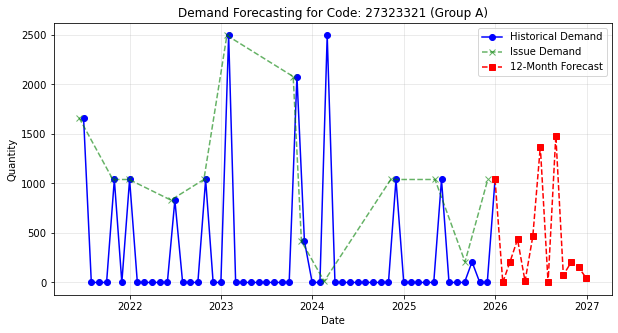

,Code,Month_1_Forecast,Month_2_Forecast,Month_3_Forecast,Month_4_Forecast,Month_5_Forecast,Month_6_Forecast,Month_7_Forecast,Month_8_Forecast,Month_9_Forecast,Month_10_Forecast,Month_11_Forecast,Month_12_Forecast,3Month_Total_Forecast,6Month_Total_Forecast,9Month_Total_Forecast,12Month_Total_Forecast
0,13847012,38,27,1,240,724,400,618,1473,1467,1430,632,425,66,1430,4988,7475
1,22016552,640,2348,459,1663,1502,1762,2447,1945,2228,1742,2141,1449,3447,8374,14994,20326
2,22017822,428,31,86,429,429,429,429,429,429,429,429,429,545,1832,3119,4406
3,22048551,8,0,630,3,0,125,178,123,45,58,87,233,638,766,1112,1490
4,27323321,0,202,436,12,466,1372,0,1484,75,202,154,42,638,2488,4047,4445


In [10]:
def fill_missing_months(group): # ماه هایی که تقاضا نبوده صفر لحاظ می شود
    group['Date_month_end'] = group['Date'] + pd.offsets.MonthEnd(0) # قرار دادن مقادیر تقاضا در آخر ماه برای یکپارچه سازی داده
    
    date_range = pd.date_range(
        start=group['Date_month_end'].min(), 
        end=group['Date_month_end'].max(),
        freq='M' #آخر ماه
        )
    complete_dates = pd.DataFrame({'Date': date_range})
    
    result = complete_dates.merge(
        group[['Date_month_end', 'Req Qty']].rename(columns={'Date_month_end': 'Date'}),
        on='Date',
        how='left')
    result['Code'] = group['Code'].iloc[0]
    result['Req Qty'] = result['Req Qty'].fillna(0).astype(int)
    return result[['Date', 'Code', 'Req Qty']]

# جداسازی اقلام پر مصرف
a_items = abc[abc['Category'] == 'A']['Code']

df_A = df[df['Code'].isin(a_items)]

# تبدیل تقاضا به سری زمانی
monthly_demand_A = df_A.groupby('Code').apply(fill_missing_months).reset_index(drop=True)

def create_lags(data, lags=3):
    df_lag = data.copy()
    for i in range(1,lags+1):
        df_lag[f'lag_{i}'] = df_lag['Req Qty'].shift(i)
    
    return df_lag.dropna()

#--------------------------
# ایجاد مدل برای هر قطعه
forecast_results = []

for code in monthly_demand_A['Code'].unique():
    item_data = monthly_demand_A[monthly_demand_A['Code']==code]
    item_data = item_data.sort_values('Date')
    
    ts = create_lags(item_data, 3)  # سه ماه
    
    if len(ts) < 5: # حداقل داده برای مدل
        continue
    
    X = ts[['lag_1', 'lag_2', 'lag_3']]
    y= ts['Req Qty']
    
    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X,y)
    
    last_three = list(item_data[['Req Qty']].tail(3)['Req Qty'].values)[::-1]
    
    future_forecasts = []
    future_dates = []
    
    current_last_date = item_data['Date'].max()
    
    for i in range(1,13): # پیش بینی 12ماهه
        pred = model.predict([last_three])[0]
        pred = max(0, round(pred))
        future_forecasts.append(pred)
        
        last_three = [pred] + last_three[:2]
        
        next_date = current_last_date + pd.DateOffset(months=i)
        future_dates.append(next_date)
    
    plt.figure(figsize=(10,5)) 
    plt.plot(item_data['Date'].to_numpy(),
             item_data['Req Qty'].to_numpy(),
             marker='o', label='Historical Demand', color='blue')
    
    raw_issues=df_A[df_A['Code'] == code][['Date', 'Issue Qty']].copy().sort_values('Date')
    plt.plot(raw_issues['Date'].to_numpy(),
             raw_issues['Issue Qty'].to_numpy(),
             marker='x', linestyle='--', color='green',
             label='Issue Demand', alpha=0.6)
    plot_dates = [item_data['Date'].iloc[-1]] + future_dates
    plot_values = [item_data['Req Qty'].iloc[-1]] +future_forecasts
    plt.plot(plot_dates, plot_values,
             marker='s', linestyle='--', color='red', 
             label='12-Month Forecast')
    plt.title(f"Demand Forecasting for Code: {code} (Group A)")
    plt.xlabel('Date')
    plt.ylabel('Quantity')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    forecast_results.append({
                'Code': code,
                **{f'Month_{i+1}_Forecast': future_forecasts[i] for i in range(12)},
                '3Month_Total_Forecast': sum(future_forecasts[i] for i in range(3)),
                '6Month_Total_Forecast': sum(future_forecasts[i] for i in range(6)),
                '9Month_Total_Forecast': sum(future_forecasts[i] for i in range(9)),
                '12Month_Total_Forecast': sum(future_forecasts)
            })
    
    
forecast_df = pd.DataFrame(forecast_results)

forecast_df

در مدل سازی باید داده باید به دو بخش آموزش و تست تقسیم شود تا امکان محاسبه خطای مدل ممکن باشد. ولی بدلیل تعداد داده های کم، در اینجا از کل داده برای آموزش استفاده شده است. اگرچه در برخی موارد با ایجاد داده های مصنوعی از طریق میان یابی حجم داده را افزایش می دهند ولی در مثال حاضر از این کار استفاده نشده و تنها مقدار پیش بینی آتی بصورت نمودار رسم شده است.

### ارزیابی حداقل و حداکثر موجودی انبار

In [11]:
LEAD_TIME_MONTHS = 3 # مدت زمان تامین کالا
SERVICE_LEVEL_Z = 1.65 # برای سطح 95 درصد
ORDER_QTY_FACTOR = 1
ORDER_MONTHS = 3 # سفارش گذاری هر 3 ماه

# محاسبه پارامترها از روی پیش بینی 12 ماهه
forecast_cols = [f'Month_{i+1}_Forecast' for i in range(12)]

# میانگین تقاضای پیش بینی شده (اینده نگر)
forecast_df['Avg_forecast'] = forecast_df[forecast_cols].mean(axis=1)

# انحراف معیار پیش بینی شده
forecast_df['Std_forecast'] = forecast_df[forecast_cols].std(axis=1, ddof=1)

# محاسبه ضریب ایمنی انبار
# SS= Z * sigma * sqrt(LT)
forecast_df['Safey_Stock'] = (SERVICE_LEVEL_Z * forecast_df['Std_forecast'] * np.sqrt(LEAD_TIME_MONTHS)).round(0)

# محاسبه حداقل قطعه در انبار
# ROP = avg Demand * LT + SS
forecast_df['Min_Stock'] = (forecast_df['Avg_forecast'] * LEAD_TIME_MONTHS + forecast_df['Safey_Stock']).round(0)

# تعیین مقدار سفارش
# حالت ساده یک ماه تقاضا
forecast_df['order_Qty'] = (forecast_df['Avg_forecast'] * ORDER_QTY_FACTOR * ORDER_MONTHS).round(0)

# محاسبه ماکزیمم قطعه در انبار
forecast_df['Max_Stock'] = (forecast_df['Min_Stock'] + forecast_df['order_Qty']).round(0)

forecast_df.head(20)

,Code,Month_1_Forecast,Month_2_Forecast,Month_3_Forecast,Month_4_Forecast,Month_5_Forecast,Month_6_Forecast,Month_7_Forecast,Month_8_Forecast,Month_9_Forecast,...,3Month_Total_Forecast,6Month_Total_Forecast,9Month_Total_Forecast,12Month_Total_Forecast,Avg_forecast,Std_forecast,Safey_Stock,Min_Stock,order_Qty,Max_Stock
0,13847012,38,27,1,240,724,400,618,1473,1467,...,66,1430,4988,7475,622.916667,557.293697,1593.0,3462.0,1869.0,5331.0
1,22016552,640,2348,459,1663,1502,1762,2447,1945,2228,...,3447,8374,14994,20326,1693.833333,624.034503,1783.0,6864.0,5082.0,11946.0
2,22017822,428,31,86,429,429,429,429,429,429,...,545,1832,3119,4406,367.166667,144.654342,413.0,1514.0,1102.0,2616.0
3,22048551,8,0,630,3,0,125,178,123,45,...,638,766,1112,1490,124.166667,176.235810,504.0,876.0,372.0,1248.0
4,27323321,0,202,436,12,466,1372,0,1484,75,...,638,2488,4047,4445,370.416667,518.586095,1482.0,2593.0,1111.0,3704.0


### با توجه به جدول فوق، به عنوان مثال برای کالای اول، انبار اصلی باید در حداقل 3462 لیتر سفارش گذاری 1869 لیتر برای 3 ماه را انجام دهد و نباید موجودی از 1593 لیتر کمتر شود تا نوسانات سه ماهه پوشش داده شود.
### همچنین میزان نیاز سالانه 7475 لیتر می باشد